# Домашнее задание: Feature Selection и PCA

## 🎯 Цели задания

1. Понять принципы анализа корреляций между признаками.

2. Освоить методы отбора признаков: Filter-метод (SelectKBest) и Wrapper-метод (RFE).

3. Изучить технику понижения размерности с помощью PCA.

4. Сравнить различные подходы и сделать выводы о их эффективности.

## 🧩 Задание

### Часть 1. Подготовка данных

In [23]:
# Импортируйте необходимые библиотеки

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from time import perf_counter

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, f1_score


In [24]:
# Загрузите датасет Wine Quality

df = pd.read_csv('winequalityN.csv')
display(df.head(5))
display(df.describe())

ln = len(df)

# Проанализируйте пропуски в данных
temp = df.count().reset_index()
temp.columns = ['column', 'count']
temp['ptc_lost'] = (1 - temp['count'] / ln) * 100
temp['dtype'] = df.dtypes.values
temp = temp[['column', 'count', 'ptc_lost', 'dtype']]
display(temp)

# копируем df и заполняем пропуски медианой в рамках типа вина
df_work = df.copy()
for column in df_work.select_dtypes(include=['float64', 'int64']).columns:
    df_work[column] = df_work.groupby('type')[column].transform(lambda x: x.fillna(x.median()))
df_work.describe()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


,column,count,ptc_lost,dtype
0,type,6497,0.000000,str
1,fixed acidity,6487,0.153917,float64
2,volatile acidity,6489,0.123134,float64
3,citric acid,6494,0.046175,float64
4,residual sugar,6495,0.030783,float64
5,chlorides,6495,0.030783,float64
6,free sulfur dioxide,6497,0.000000,float64
7,total sulfur dioxide,6497,0.000000,float64
8,density,6497,0.000000,float64
9,pH,6488,0.138525,float64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.216277,0.339633,0.318713,5.444251,0.056038,30.525319,115.744574,0.994697,3.218382,0.531224,10.491801,5.818378
std,1.295889,0.164584,0.145233,4.757394,0.035031,17.749400,56.521855,0.002999,0.160650,0.148780,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [25]:
# Сформируйте задачу бинарной классификации:
# качество ≥ 7 → класс 1 (высокое качество), иначе → класс 0

df_work['hight_quality_class'] = (df_work['quality'] >= 7).astype(int)
df_work['red_type_wine'] = (df_work['type']=='red').astype(int)
df_work.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,hight_quality_class,red_type_wine
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,0,0
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,0,0
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,0,0
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0,0
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0,0


In [26]:
# Удалите исходный признак quality

df_work = df_work.drop('quality', axis=1)
# ТАкже удаляем type так как привел к бинарному виду
df_work = df_work.drop('type', axis=1)

In [27]:
# Разделите данные на train (70%) и test (30%) с stratify по целевой переменной

feature_columns = [col for col in df_work.columns if col != 'hight_quality_class']
X_base = df_work[feature_columns]  # признаки кроме таргета
y = df_work[['hight_quality_class']]       # целевая переменная (0/1)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y,
    test_size=0.3,         
    stratify=y,           
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4547, 12) Test: (1950, 12)


### Часть 2. Анализ корреляций

<Axes: >

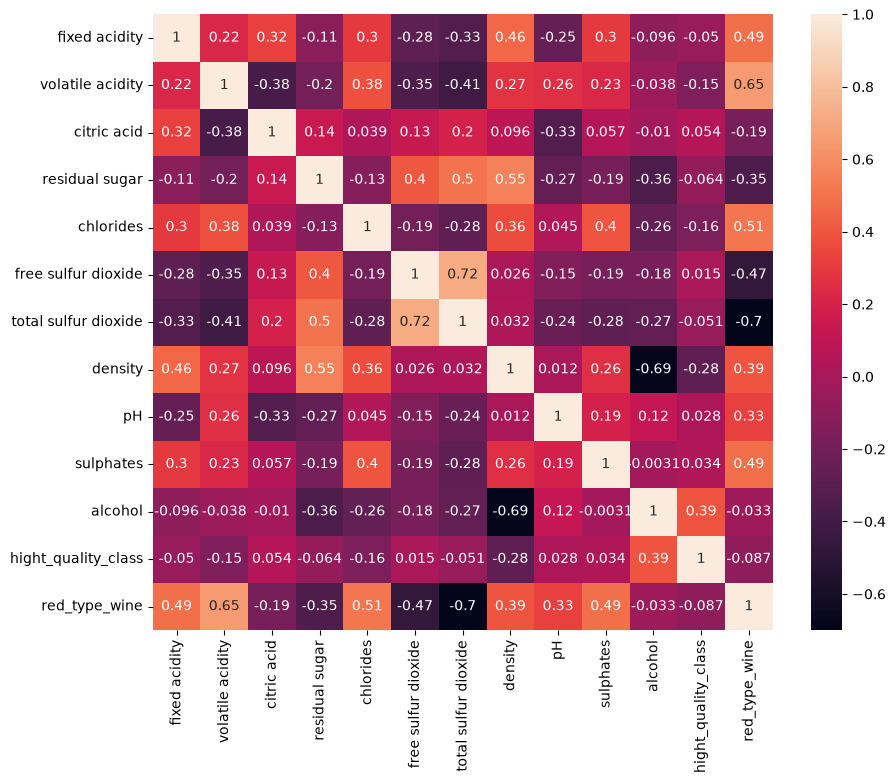

In [28]:
# Постройте тепловую карту корреляций Пирсона для всех числовых признаков


col_nums=df_work.select_dtypes(include='number').columns
corr = df_work[col_nums].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='rocket', cbar=True)

In [29]:
# Найдите пары признаков с |корреляция| > 0.7

mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
set_corr = corr.where(mask).stack()
set_corr = set_corr[abs(set_corr) > 0.7]
set_corr

free sulfur dioxide   total sulfur dioxide    0.720934
total sulfur dioxide  red_type_wine          -0.700357
dtype: float64

# Объясните, почему такие признаки могут ухудшать модель

Сильно коррелирующие признаки дублируют информацию. Это увеличивает риск переобучения. В линейных моделях такие признаки делают веса ненадежными, потому что модель не может решить, кому из них приписать влияние. В нашем случае free sulfur dioxide является частью total sulfur dioxide, поэтому его можно удалить без потери информации.

In [30]:
# Удалите один признак из каждой сильно коррелирующей пары
# (оставьте тот, у которого корреляция с таргетом выше)

feature = corr.reset_index().rename(columns={'index': 'feature'})
feature = feature[feature['feature'].isin(['red_type_wine','total sulfur dioxide','free sulfur dioxide'])][['feature','hight_quality_class']]
feature


# Сравниваем модули корреляций с таргетом (таблица выше):
# пара (free sulfur dioxide, total sulfur dioxide): |0.015| < |0.051| оставляем total, убираем free
# пара (total sulfur dioxide, red_type_wine): |0.051| < |0.087| оставляем red_type_wine, убираем total
# Итог: total участвует в обеих парах и проигрывает в парах удаляем оба total sulfur dioxide признака
drop_columns = ['free sulfur dioxide', 'total sulfur dioxide']
X_train = X_train.drop(columns=drop_columns)
X_test = X_test.drop(columns=drop_columns)

print('X_train:', X_train.shape, 'X_test:', X_test.shape)


X_train: (4547, 10) X_test: (1950, 10)


### Часть 3. Filter-методы отбора

In [ ]:
# Примените SelectKBest для отбора топ-5 признаков

y_train_1d = y_train.values.ravel()
y_test_1d = y_test.values.ravel()

selector_kbest = SelectKBest(score_func=f_classif, k=5)
X_train_kbest = selector_kbest.fit_transform(X_train, y_train_1d)
X_test_kbest = selector_kbest.transform(X_test)

# Список отобранных признаков
kbest_features = X_train.columns[selector_kbest.get_support()].tolist()
print('Отобранные признаки (SelectKBest):')
print(kbest_features)


Отобранные признаки (SelectKBest):
['volatile acidity', 'chlorides', 'density', 'alcohol', 'red_type_wine']


In [ ]:
# Обучите логистическую регрессию на отобранных признаках
lr_kbest_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE))
])

t0 = perf_counter()
lr_kbest_pipe.fit(X_train_kbest, y_train_1d)
print('Время обучения, сек:', round(perf_counter() - t0, 4))


Время обучения, сек: 0.0057


In [ ]:
# Оцените ROC-AUC на тестовой выборке

y_prob_kbest = lr_kbest_pipe.predict_proba(X_test_kbest)[:, 1]
kbest_auc = roc_auc_score(y_test_1d, y_prob_kbest)
print('ROC-AUC (SelectKBest):', round(kbest_auc, 4))


ROC-AUC (SelectKBest): 0.7949


### Часть 4. Wrapper метод (RFE)

In [ ]:
# Примените RFE с логистической регрессией в качестве оценивающей модели
# для отбора 5 признаков

rfe_selector = RFE(
    estimator=LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE),
    n_features_to_select=5,
    step=1
)
X_train_rfe = rfe_selector.fit_transform(X_train, y_train_1d)
X_test_rfe = rfe_selector.transform(X_test)

# Список отобранных признаков
rfe_features = X_train.columns[rfe_selector.get_support()].tolist()
print('Отобранные признаки (RFE):')
print(rfe_features)


Отобранные признаки (RFE):
['volatile acidity', 'chlorides', 'density', 'sulphates', 'alcohol']


In [ ]:
# Обучите логистическую регрессию на отобранных признаках

lr_rfe_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE))
])

t0 = perf_counter()
lr_rfe_pipe.fit(X_train_rfe, y_train_1d)
print('Время обучения, сек:', round(perf_counter() - t0, 4))


Время обучения, сек: 0.0043


In [ ]:
# Оцените ROC-AUC на тестовой выборке

y_prob_rfe = lr_rfe_pipe.predict_proba(X_test_rfe)[:, 1]
rfe_auc = roc_auc_score(y_test_1d, y_prob_rfe)
print('ROC-AUC (RFE):', round(rfe_auc, 4))


ROC-AUC (RFE): 0.7971


In [ ]:
# Сравните набор признаков, отобранных через SelectKBest и RFE

common = sorted(set(kbest_features) & set(rfe_features))
only_kbest = sorted(set(kbest_features) - set(rfe_features))
only_rfe = sorted(set(rfe_features) - set(kbest_features))

print('Общие признаки (SelectKBest и RFE):')
print(common)
print('\nТолько SelectKBest:')
print(only_kbest)
print('\nТолько RFE:')
print(only_rfe)


Общие признаки (SelectKBest и RFE):
['alcohol', 'chlorides', 'density', 'volatile acidity']

Только SelectKBest:
['red_type_wine']

Только RFE:
['sulphates']


In [ ]:
# Объясните различия


# Различия:
# - SelectKBest оценивает каждый признак отдельно (ANOVA F-критерий), не учитывая
#   взаимодействие признаков друг с другом.
# - RFE оценивает важность признаков в контексте модели: рекурсивно удаляет
#   наименее важные, переобучая логистическую регрессию на каждом шаге.
# Поэтому наборы отличаются: RFE нашёл sulphates (важен именно вместе с другими
# признаками), а SelectKBest выбрал red_type_wine, который силён по отдельности,
# но для модели частично дублирует информацию других признаков.


### Часть 5. Преобразование признаков (PCA)

In [ ]:
# Примените StandardScaler к данным (обязательно перед PCA!)

scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled = scaler_pca.transform(X_test)


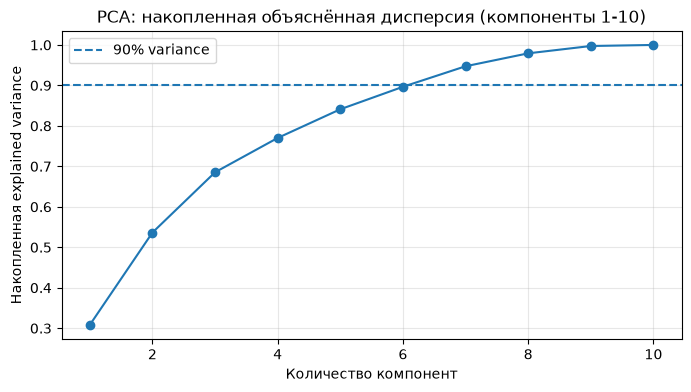

In [ ]:
# Постройте график накопленной объяснённой дисперсии для компонент от 1 до 10

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 11), cum_var[:10], marker='o')
plt.axhline(0.9, linestyle='--', label='90% variance')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная explained variance')
plt.title('PCA: накопленная объяснённая дисперсия (компоненты 1-10)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Определите минимальное число компонент, объясняющих ≥ 90% дисперсии

n90 = int(np.searchsorted(cum_var, 0.9) + 1)
print('Число компонент для >=90% дисперсии:', n90)


Число компонент для >=90% дисперсии: 7


In [ ]:
# Обучите логистическую регрессию на полученных компонентах

lr_pca_pipe = Pipeline([
    ('pca', PCA(n_components=n90, random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE))
])

t0 = perf_counter()
lr_pca_pipe.fit(X_train_scaled, y_train_1d)
print('Время обучения, сек:', round(perf_counter() - t0, 4))


Время обучения, сек: 0.0063


In [ ]:
# Оцените ROC-AUC на тестовой выборке

y_prob_pca = lr_pca_pipe.predict_proba(X_test_scaled)[:, 1]
pca_auc = roc_auc_score(y_test_1d, y_prob_pca)
print('ROC-AUC (PCA):', round(pca_auc, 4))


ROC-AUC (PCA): 0.7892


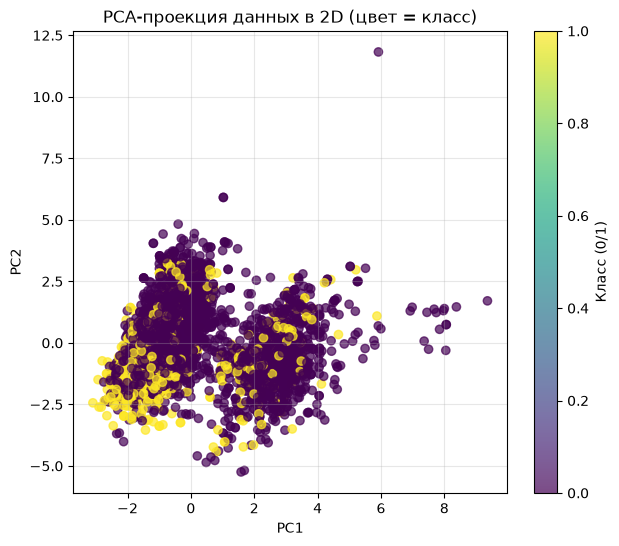

In [ ]:
# Визуализируйте данные в пространстве первых двух главных компонент
# раскрасив точки по целевому классу

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_1d, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA-проекция данных в 2D (цвет = класс)')
plt.grid(alpha=0.3)
plt.colorbar(scatter, label='Класс (0/1)')
plt.show()


## 📝 Выводы

Сформулируйте общий вывод:  
Какой подход показал лучший баланс между качеством, скоростью и интерпретируемостью?

**Сравнение подходов (ROC-AUC на тестовой выборке):**

| Подход | ROC-AUC | Число признаков/компонент |
|---|---|---|
| SelectKBest | 0.7949 | 5 |
| RFE | 0.7971 | 5 |
| PCA | 0.7892 | 7 |

- **SelectKBest** — быстрый filter-отбор: оценивает каждый признак по отдельности, не учитывая их взаимодействие. Хороший баланс: всего 5 признаков, качество практически не проседает.
- **RFE** — wrapper-метод: учитывает вклад признаков в контексте модели, поэтому показал лучший ROC-AUC (0.7971). Требует переобучения модели на каждом шаге, но при таком масштабе данных разница во времени обучения незаметна.
- **PCA** — максимально компактен (7 компонент дают 90% дисперсии), но его компоненты — это комбинации исходных признаков, поэтому они хуже интерпретируются, а качество оказалось чуть ниже остальных (0.7892).

**Итог:** лучший баланс качества, скорости и интерпретируемости — у **RFE**: он отобрал 5 исходных признаков (интерпретируемо) и дал максимум качества. SelectKBest почти не уступает по качеству при минимальной сложности, поэтому тоже хорош для первичного сжатия. PCA полезен для визуализации и сильного сжатия, но ценой интерпретируемости и небольшой просадки качества.
